In [28]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
from sklearn.model_selection import KFold
from statsmodels.formula.api import mixedlm
from sklearn.metrics import mean_squared_error
from patsy import dmatrix

In [29]:
def clean_data(df):
    gym_data = df.copy()
    
    gym_data.columns = gym_data.columns.str.lower()
    
    gym_data['round'] = gym_data['round'].replace({ 'AAqual': 'qual', 'TeamQual': 'qual'
    }, regex=True)
    
    gym_data['location'] = gym_data['location'].str.replace(r'\.', '', regex=True)

    gym_data['country'] = gym_data['country'].replace({
        'GE1': 'GER', 'GE2': 'GER', 'NIR': 'IRL',
        'ENG': 'GBR', 'SCO': 'GBR', 'WAL': 'GBR', 'IOM': 'GBR',
        'SIN': 'SGP', '': np.nan
    }, regex=True)
    
    gym_data['firstname'] = gym_data['firstname'].str.title().str.strip()
    gym_data['lastname'] = gym_data['lastname'].str.title().str.strip()
    
    gym_data['fullname'] = (gym_data['firstname'] + ' ' + gym_data['lastname']).str.strip()
    
    # Calculate NA penalty values
    mask = gym_data['penalty'].isna()
    gym_data.loc[mask, 'penalty'] = np.maximum(0, 
        np.round(gym_data.loc[mask, 'd_score'] + gym_data.loc[mask, 'e_score'] - gym_data.loc[mask, 'score'], 3))
    
    # Filter competition locations to country
    gym_data['location'] = gym_data['location'].str.replace(r'.*, ', '', regex=True)
    gym_data['location'] = gym_data['location'].replace({
        'Utah': 'United States', 'Illinois': 'United States', 'FL': 'United States', 
        'CA': 'United States', 'Kentucky': 'United States', 'Texas': 'United States',
        'England': 'United Kingdom'
    }, regex=True)
    
    # Fix apparatus names
    gym_data['apparatus'] = gym_data['apparatus'].replace({
        'hb': 'HB', 'VT1': 'VT', 'VT2': 'VT'
    }, regex=True)
    
       # 去除不必要的字符串
    gym_data['date'] = gym_data['date'].str.replace(r'sun|thu', '', regex=True, case=False)
    gym_data['date'] = gym_data['date'].str.replace(r'.*-', '', regex=True)
    gym_data['date'] = gym_data['date'].str.title().str.strip()
    gym_data['date'] = gym_data['date'].replace({
        'June': 'Jun', 'July': 'Jul', 'Sept': 'Sep', ',': ''
    }, regex=True)

    # 定义解析日期的函数
    def parse_date(date_str):
        try:
            return datetime.strptime(date_str, "%d %b %Y").date()
        except:
            try:
                return datetime.strptime(date_str, "%d %B %Y").date()
            except:
                return np.nan

    # 使用解析函数转换日期格式
    gym_data['date'] = gym_data['date'].apply(parse_date)

    # 检查是否有未能成功解析的日期
    if gym_data['date'].isna().any():
        print("Warning: dates may not have processed properly. Some dates now NA.")
        gym_data = gym_data.drop_duplicates()
    
    return gym_data

df_old = pd.read_csv('data_2017_2021.csv')
df_new = pd.read_csv('data_2022_2023.csv')

df_old = clean_data(df_old)
df_new = clean_data(df_new)


In [30]:
target_countries = ['USA', 'GBR', 'CAN', 'BRA', 'FRA', 'CHN', 'JPN', 'NED', 'ITA', 'AUS', 'ROU', 'KOR']

df_old = df_old[df_old['country'].isin(target_countries)]
df_new = df_new[df_new['country'].isin(target_countries)]

In [31]:

df_new.loc[df_new['fullname'] == "Aiden Frick", 'fullname'] = "Aiden Michael Frick"

df_new.loc[df_new['fullname'] == "Clay Masonstephens", 'fullname'] = "Clay Mason Stephens"

df_new.loc[df_new['fullname'] == "Emily Whitehead", 'gender'] = "w"

df_new.loc[df_new['fullname'] == "Georgia Godwin", 'gender'] = "w"

df_new.loc[df_new['fullname'] == "Kiplin Smith", 'fullname'] = "Kiplin Morrish Smith"


df_new.loc[df_new['fullname'] == "Cassandra Lee", 'fullname'] = "Cassandra Paige Lee"

df_new.loc[df_new['fullname'] == "Ellie Black", 'fullname'] = "Elsabeth Black"

df_new.loc[df_new['fullname'] == "Emma Spence", 'gender'] = "w"

df_new.loc[df_new['fullname'] == "Jenna Lalonde", 'gender'] = "w"

df_new.loc[df_new['fullname'] == "Laurie Denommée", 'fullname'] = "Laurie Denommee"
df_new.loc[df_new['fullname'] == "Laurie Denommee", 'gender'] = "w"

df_new.loc[df_new['fullname'] == "Sam Zakutney", 'fullname'] = "Samuel Zakutney"

df_new.loc[df_new['fullname'] == "Sydney Turner", 'fullname'] = "Sydney Leslie Turner"

df_new.loc[df_new['fullname'] == "Zachary Clay", 'fullname'] = "Zachary Nathaniel Clay"

mask_bernardo = (
    (df_new['fullname'] == "Bernardo Actos Andrade De Souza Miranda") |
    (df_new['fullname'] == "Bernardo Miranda")
)
df_new.loc[mask_bernardo, 'fullname'] = "Bernardo Actos Miranda"

df_new.loc[df_new['fullname'] == "Carolyne Pedro", 'fullname'] = "Carolyne Mercer Winche Pedro"

df_new.loc[df_new['fullname'] == "Julia Soares", 'fullname'] = "Julia Das Neves Botega Soares"

mask_lucas = (
    (df_new['fullname'] == "Lucas Souza Bitencourt") |
    (df_new['fullname'] == "Lucas Bitencourt")
)
df_new.loc[mask_lucas, 'fullname'] = "Lucas De Souza Bitencourt"

df_new.loc[df_new['fullname'] == "Luisa Maia", 'fullname'] = "Luisa Gomes Maia"

mask_patrick = (
    (df_new['fullname'] == "Patrick Correa") |
    (df_new['fullname'] == "Patrick Sampaio")
)
df_new.loc[mask_patrick, 'fullname'] = "Patrick Sampaio Correa"

df_new.loc[df_new['fullname'] == "Tomas Florencio", 'fullname'] = "Tomas Rodrigues Florencio"

df_new.loc[df_new['fullname'] == "Yuri Guimarães", 'fullname'] = "Yuri Guimaraes"

df_new.loc[df_new['fullname'] == "Max Whitlock", 'fullname'] = "Max Whitlock Obe"
df_new.loc[df_new['fullname'] == "Pavel Karenejenko", 'fullname'] = "Pavel Karnejenko"
df_new.loc[df_new['fullname'] == "Poppy Stickler", 'fullname'] = "Poppy Grace Stickler"
df_new.loc[df_new['fullname'] == "Ruby Evan", 'fullname'] = "Ruby Evans"

gbr_female_athletes = [
    "Alice Kinsella", "Cara Kennedy", "Eilidh Gorrell", "Emily Bremner",
    "Georgia Mae Fenton", "Jea Maracha", "Mia Evans", "Ondine Achampong",
    "Poppy Grace Stickler", "Shannon Archer", "Tara Donnelly"
]
for name in gbr_female_athletes:
    df_new.loc[df_new['fullname'] == name, 'gender'] = "w"


df_new.loc[df_new['fullname'] == "Léa Franceries", 'fullname'] = "Lea Franceries"
df_new.loc[df_new['fullname'] == "Léo Saladino", 'fullname'] = "Leo Saladino"

mask_melanie = (
    (df_new['fullname'] == "Mélanie De Jesus Dos Santos") |
    (df_new['fullname'] == "Melanie Jesus Santos")
)
df_new.loc[mask_melanie, 'fullname'] = "Melanie De Jesus Dos Santos"


df_new.loc[df_new['fullname'] == "Morgane Osyssek", 'fullname'] = "Morgane Osyssek Reimer"


df_new.loc[df_new['fullname'] == "Garam Bae", 'fullname'] = "Ga-Ram Bae"
df_new.loc[df_new['fullname'] == "Jinseong Yun", 'fullname'] = "Jin-Seong Yun"
df_new.loc[df_new['fullname'] == "Yoseop Jeon", 'fullname'] = "Yo-Seop Jeon"



df_new.loc[df_new['fullname'] == "Jermain Grünberg", 'fullname'] = "Jermain Gruenberg"
df_new.loc[df_new['fullname'] == "Loran Munck", 'fullname'] = "Loran De Munck"
df_new.loc[df_new['fullname'] == "Martijn Veer", 'fullname'] = "Martijn De Veer"
df_new.loc[df_new['fullname'] == "Tisha Volleman", 'fullname'] = "Tisha Manouk Gijs Volleman"
df_new.loc[df_new['fullname'] == "Vera Pol", 'fullname'] = "Vera Van Pol"
df_new.loc[df_new['fullname'] == "Wout Teillers", 'fullname'] = "Wout Johan Alexander Teillers"



df_new.loc[df_new['fullname'] == "Andrei Muntean", 'fullname'] = "Andrei Vasile Muntean"


df_new.loc[df_new['fullname'] == "Razvan Denis Marc", 'fullname'] = "Razvan-Denis Marc"

mask_toma = (
    (df_new['fullname'] == "Toma Roland Modoianu Zseder") |
    (df_new['fullname'] == "Toma Modoianu-Zseder") |
    (df_new['fullname'] == "Toma Modoianu Zseder")
)
df_new.loc[mask_toma, 'fullname'] = "Toma Roland Modoianu-Zseder"



df_new.loc[df_new['fullname'] == "Curran Phillips", 'fullname'] = "Curran Michael Phillips"
df_new.loc[df_new['fullname'] == "Ian Skirkey", 'fullname'] = "Ian Hunter Skirkey"
df_new.loc[df_new['fullname'] == "Joscelyn Roberson", 'fullname'] = "Joscelyn Michelle Roberson"
df_new.loc[df_new['fullname'] == "Joshua Karnes", 'fullname'] = "Joshua Andrew Karnes"
df_new.loc[df_new['fullname'] == "Khoi Young", 'fullname'] = "Khoi Alexander Young"
df_new.loc[df_new['fullname'] == "Matt Cormier", 'fullname'] = "Matthew Cormier"
df_new.loc[df_new['fullname'] == "Nola Matthews", 'fullname'] = "Nola Rhianne Matthews"
df_new.loc[df_new['fullname'] == "Shane Wiskus", 'fullname'] = "Shane Michael Wiskus"
df_new.loc[df_new['fullname'] == "Taylor Christopulos", 'fullname'] = "Taylor Troy Christopulos"
df_new.loc[df_new['fullname'] == "Yul Moldauer", 'fullname'] = "Yul Kyung Tae Moldauer"

mask_fred = (
    (df_new['fullname'] == "Frederick Richard") |
    (df_new['fullname'] == "Fred Richard")
)
df_new.loc[mask_fred, 'fullname'] = "Frederick Nathaniel Richard"

In [32]:
df_old = df_old[df_old["gender"] == "w"]
df_new = df_new[df_new["gender"] == "w"]


In [33]:
df_new['round'].unique()

array(['qual', 'TeamFinal', 'final', 'AAfinal'], dtype=object)

In [34]:
df_new['date'] = pd.to_datetime(df_new['date'])
df_old['date'] = pd.to_datetime(df_old['date'])
df_new['days_before_event'] = (pd.to_datetime('2024-07-25') - df_new['date']).dt.days
df_old['days_before_event'] = (pd.to_datetime('2024-07-25') - df_old['date']).dt.days
df_new['fullname_mean'] = df_new.groupby('fullname')['score'].transform('mean')
df_old['fullname_mean'] = df_old.groupby('fullname')['score'].transform('mean')                                                           

In [35]:
df_new.head()

,lastname,firstname,gender,country,date,competition,round,location,apparatus,rank,d_score,e_score,penalty,score,fullname,days_before_event,fullname_mean
168,Abdullahi,Ayesha,w,GBR,2022-03-27,2022 British Gymnastics Championships,qual,United Kingdom,BB,41.0,3.7,6.500,0.0,10.200,Ayesha Abdullahi,851,10.20000
169,Abdullahi,Ayesha,w,GBR,2022-03-27,2022 British Gymnastics Championships,qual,United Kingdom,UB,45.0,3.5,6.700,0.0,10.200,Ayesha Abdullahi,851,10.20000
245,Achampong,Ondine,w,GBR,2022-11-06,2022 51st FIG Artistic Gymnastics World Champi...,qual,United Kingdom,BB,15.0,5.7,7.266,0.0,12.966,Ondine Achampong,627,13.38998
246,Achampong,Ondine,w,GBR,2022-11-06,2022 51st FIG Artistic Gymnastics World Champi...,TeamFinal,United Kingdom,BB,NaN,5.7,8.000,0.0,13.700,Ondine Achampong,627,13.38998
247,Achampong,Ondine,w,GBR,2022-11-06,2022 51st FIG Artistic Gymnastics World Champi...,qual,United Kingdom,FX,16.0,5.3,8.033,-0.0,13.333,Ondine Achampong,627,13.38998


In [36]:
selected_feature = ['country', 'round', 'apparatus', 'location', 'score', 'fullname', 'days_before_event', 'fullname_mean']

df_new = df_new[selected_feature]
df_old = df_old[selected_feature]
df_old = df_old.dropna()

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df_new['days_before_event'] = scaler.fit_transform(df_new[['days_before_event']])
df_old['days_before_event'] = scaler.fit_transform(df_old[['days_before_event']])

In [53]:
# df_old_filtered = df_old[df_old['fullname'].isin(df_new['fullname'])]
# df = pd.concat([df_new, df_old_filtered], ignore_index=True)
df = df_new
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Assume df is already loaded and contains 'round', 'apparatus', 'location', 'days_before_event', 'score'
features = ['round', 'apparatus', 'location', 'days_before_event', 'fullname_mean']
target = 'score'

# Split the data, using 80% for training and 20% for testing
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define categorical and numerical features
categorical_features = ['round', 'apparatus', 'location']
numeric_features = ['days_before_event', 'fullname_mean']

# Construct the preprocessor, applying one-hot encoding to categorical variables and passing through numerical data
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# Build the pipeline model, with the preprocessor followed by linear regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
model.fit(X_train, y_train)

# Make predictions and calculate RMSE
y_pred = model.predict(X_test)
rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))
print("Linear Regression RMSE:", rmse_model)

# Baseline model: Predict using the mean of 'score' from the training set
mean_score = X_test['fullname_mean']
baseline_pred = np.full_like(y_test, mean_score, dtype=float)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_pred))
print("Baseline Model (Mean Prediction) RMSE:", rmse_baseline)

model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train the Random Forest model
model_rf.fit(X_train, y_train)

# Make predictions and calculate RMSE
y_pred_rf = model_rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)

Linear Regression RMSE: 0.6881431682523715
Baseline Model (Mean Prediction) RMSE: 0.7496744692681299
Random Forest RMSE: 0.7089525040370278


In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.ensemble import RandomForestRegressor

# Assume df is already loaded and contains 'round', 'apparatus', 'location', 'days_before_event', 'score'
features = ['round', 'apparatus', 'location', 'days_before_event', 'fullname_mean']
target = 'score'

# Split the data, using 80% for training and 20% for testing
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4)

# Define categorical and numerical features
categorical_features = ['round', 'apparatus', 'location']
numeric_features = ['days_before_event', 'fullname_mean']

# Construct the preprocessor, applying one-hot encoding to categorical variables and passing through numerical data
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# Build the pipeline model, with the preprocessor followed by linear regression
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Build the pipeline model for Random Forest
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Define a scorer for RMSE
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)

# Perform 5-fold cross-validation for Linear Regression
kfold = KFold(n_splits=5, shuffle=True, random_state=4)
lr_scores = cross_val_score(model_lr, X_train, y_train, cv=kfold, scoring=rmse_scorer)
print("Linear Regression 5-Fold CV RMSE: ", np.mean(-lr_scores))  # Take the negative because greater_is_better=False

# Perform 5-fold cross-validation for Random Forest
rf_scores = cross_val_score(model_rf, X_train, y_train, cv=kfold, scoring=rmse_scorer)
print("Random Forest 5-Fold CV RMSE: ", np.mean(-rf_scores))  # Take the negative because greater_is_better=False

# Baseline model: Predict using the mean of 'score' from the training set
mean_score = X_test['fullname_mean']
baseline_pred = np.full_like(y_test, mean_score, dtype=float)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_pred))
print("Baseline Model (Mean Prediction) RMSE:", rmse_baseline)

Linear Regression 5-Fold CV RMSE:  0.7273592320328124
Random Forest 5-Fold CV RMSE:  0.7618592213694821
Baseline Model (Mean Prediction) RMSE: 0.7600562291427706


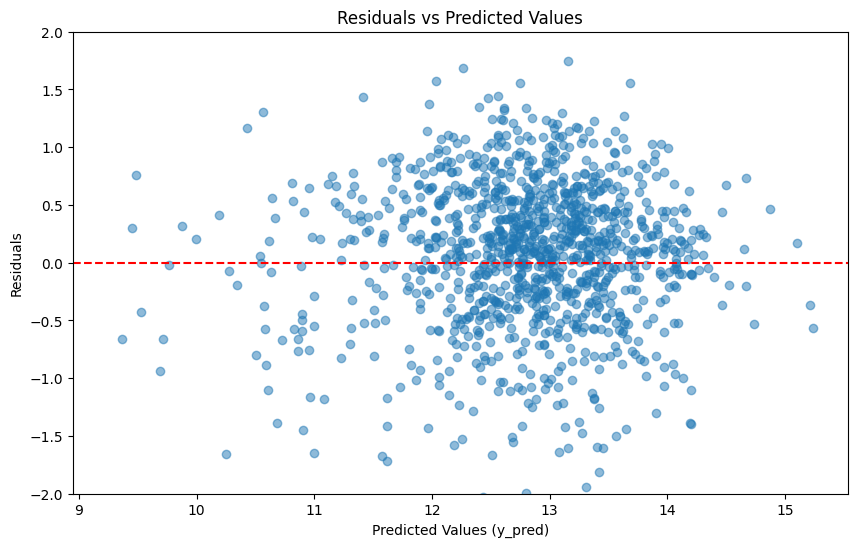

In [19]:
import matplotlib.pyplot as plt

# 计算残差
residuals = y_test - y_pred

# 绘制残差 vs 预测值
plt.figure(figsize=(10, 6))
plt.ylim(-2, 2)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values (y_pred)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

In [12]:
import numpy as np
import pandas as pd

# 获取 one-hot 编码后的类别特征名称
cat_feature_names = model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(categorical_features)

# 合并所有特征名称，注意顺序要与模型训练时的顺序一致
all_feature_names = np.concatenate([cat_feature_names, numeric_features])

# 获取线性回归模型的系数
coefs = model.named_steps['regressor'].coef_

# 创建一个 DataFrame 展示每个特征的系数和其绝对值（作为重要性的度量）
feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coefs,
    'abs_coefficient': np.abs(coefs)
})

# 按照绝对值排序
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)
print(feature_importance)


                    feature  coefficient  abs_coefficient
27            fullname_mean     0.958685         0.958685
7              apparatus_VT     0.467532         0.467532
4              apparatus_BB    -0.356576         0.356576
22        location_Slovenia     0.317358         0.317358
16          location_France    -0.260103         0.260103
19          location_Israel    -0.235973         0.235973
15           location_Egypt    -0.223087         0.223087
11           location_Chile     0.161565         0.161565
14         location_Croatia    -0.153761         0.153761
13        location_Colombia     0.151164         0.151164
21       location_Singapore     0.116389         0.116389
0             round_AAfinal    -0.105562         0.105562
2               round_final     0.100746         0.100746
5              apparatus_FX    -0.076174         0.076174
8       location_Azerbaijan    -0.066670         0.066670
9          location_Belgium     0.054247         0.054247
10        loca

In [13]:
encoded_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = np.concatenate([encoded_features, numeric_features])

# 获取随机森林模型的特征重要性
feature_importances = model_rf.named_steps['regressor'].feature_importances_

# 转换为 DataFrame，方便排序和可视化
importance_df = pd.DataFrame({'Feature': all_features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 显示特征重要性
print(importance_df)

                    Feature  Importance
27            fullname_mean    0.667362
7              apparatus_VT    0.073304
26        days_before_event    0.066652
6              apparatus_UB    0.022524
4              apparatus_BB    0.021534
5              apparatus_FX    0.019803
3                round_qual    0.014150
2               round_final    0.013493
25   location_United States    0.012921
0             round_AAfinal    0.011022
24  location_United Kingdom    0.010627
20           location_Qatar    0.008181
1           round_TeamFinal    0.006771
16          location_France    0.005986
17         location_Germany    0.005881
23          location_Turkey    0.005463
8       location_Azerbaijan    0.004794
12           location_China    0.004641
14         location_Croatia    0.004372
15           location_Egypt    0.004196
9          location_Belgium    0.003857
10        location_Bulgaria    0.003850
21       location_Singapore    0.002300
13        location_Colombia    0.002053


In [14]:
df.to_csv('data.csv', index=False, encoding='utf-8')

In [49]:
df_new.iloc[-13:-10]

,country,round,apparatus,location,score,fullname,days_before_event,fullname_mean
24332,CAN,qual,VT,Germany,11.45,Evandra Zlobec,494,12.112500
24349,CAN,qual,UB,United Kingdom,10.55,Maya Zonneveld,723,10.550000
24391,CHN,qual,BB,Singapore,13.30,Tong Zuo,403,13.466273
